# RF Entropy — 4 Split Ratios Comparison

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
sns.set_palette('Blues');plt.rcParams['axes.prop_cycle']=plt.cycler(color=plt.cm.Blues(np.linspace(0.3,0.9,8)))
import warnings;warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('../../datasets/augmented_data.csv');X=df.drop('diagnosis',axis=1);y=df['diagnosis']

90/10: Acc:0.9800 Prec:1.0000 Rec:0.9600 F1:0.9796 Spec:1.0000 AUC:0.9996
80/20: Acc:0.9750 Prec:1.0000 Rec:0.9500 F1:0.9744 Spec:1.0000 AUC:0.9962
70/30: Acc:0.9701 Prec:1.0000 Rec:0.9400 F1:0.9691 Spec:1.0000 AUC:0.9921
60/40: Acc:0.9650 Prec:0.9794 Rec:0.9500 F1:0.9645 Spec:0.9800 AUC:0.9867


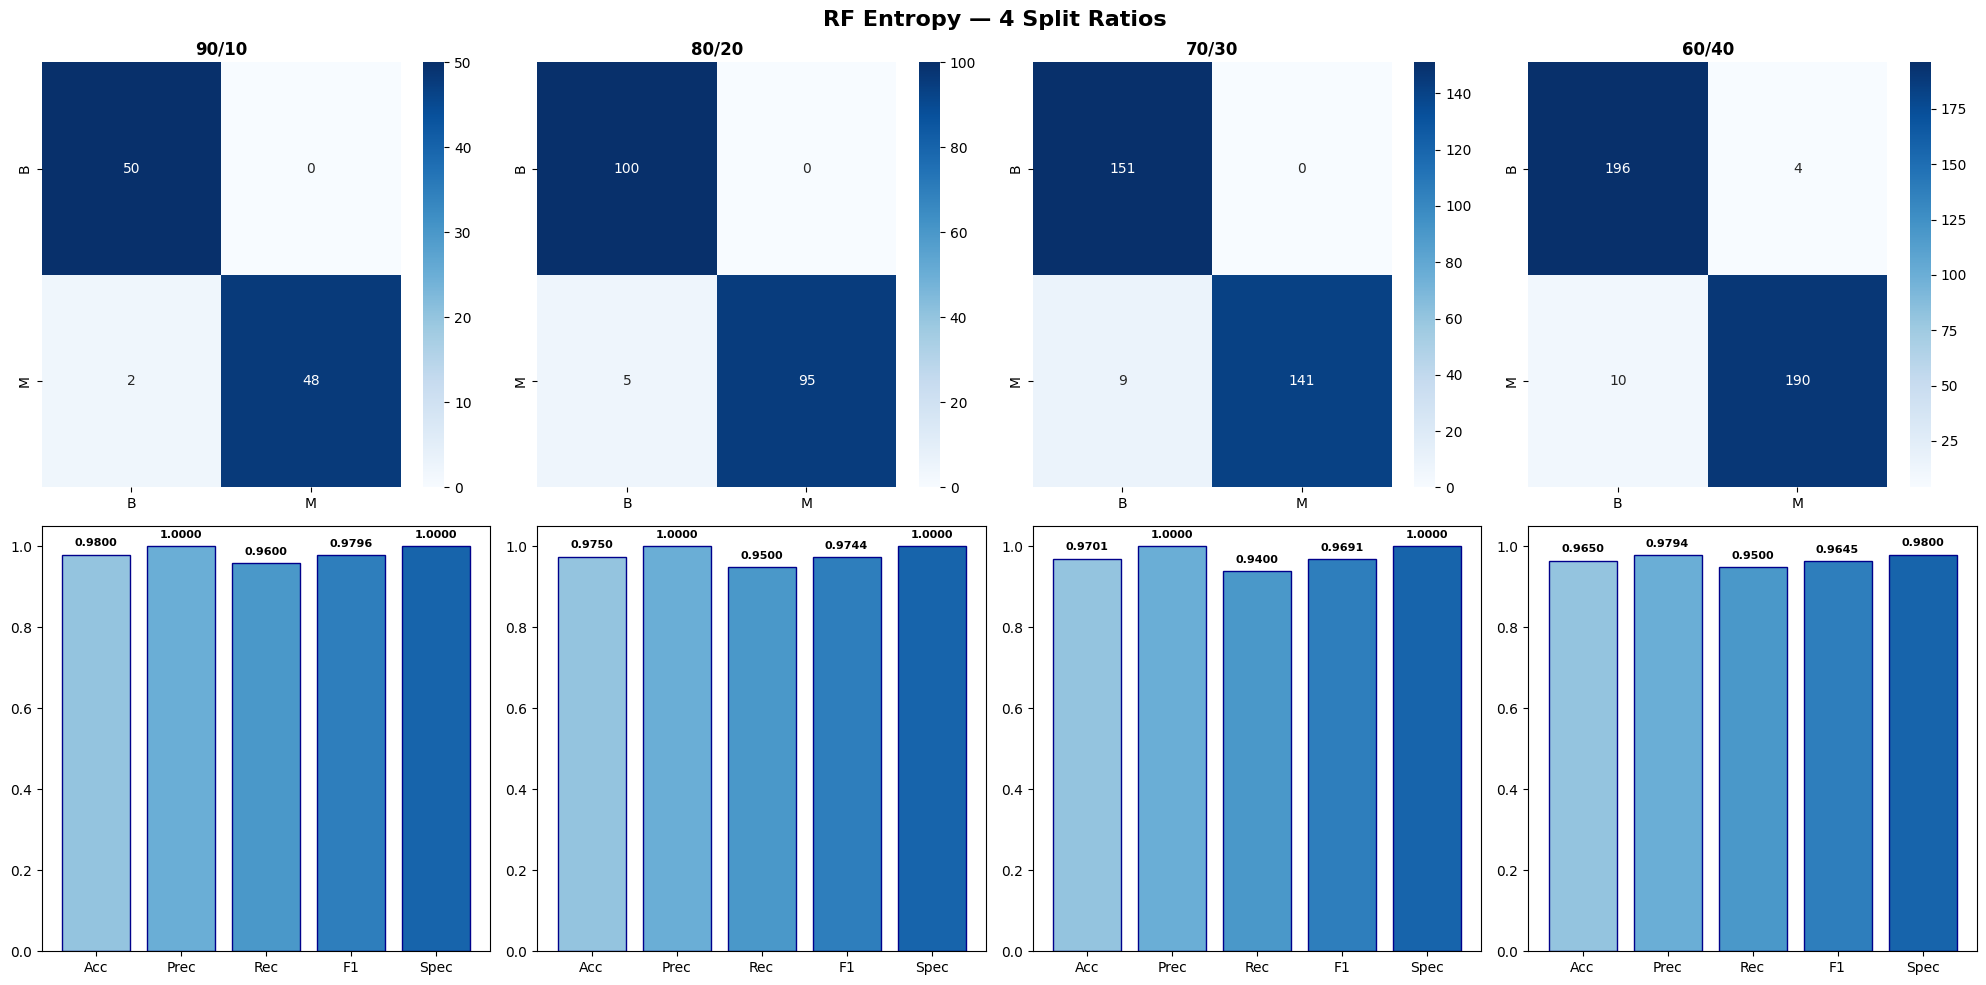

In [3]:
ratios=[0.9,0.8,0.7,0.6];labels=['90/10','80/20','70/30','60/40'];results=[]
fig,axes=plt.subplots(2,4,figsize=(20,10))
fig.suptitle('RF Entropy — 4 Split Ratios',fontsize=16,fontweight='bold')
for idx,(ratio,label) in enumerate(zip(ratios,labels)):
    ts=1-ratio
    X_tr,X_te,y_tr,y_te=train_test_split(X,y,test_size=ts,random_state=42,stratify=y)
    sc=StandardScaler();X_tr=sc.fit_transform(X_tr);X_te=sc.transform(X_te)
    m=RandomForestClassifier(criterion='entropy',random_state=42).fit(X_tr,y_tr)
    yp=m.predict(X_te);ypb=m.predict_proba(X_te)[:,1]
    acc=accuracy_score(y_te,yp);prec=precision_score(y_te,yp);rec=recall_score(y_te,yp);f1=f1_score(y_te,yp)
    cm=confusion_matrix(y_te,yp);tn,fp,fn,tp=cm.ravel();spec=tn/(tn+fp);auc=roc_auc_score(y_te,ypb)
    results.append({'Ratio':label,'Acc':acc,'Prec':prec,'Rec':rec,'F1':f1,'Spec':spec,'AUC':auc})
    print(f"{label}: Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} Spec:{spec:.4f} AUC:{auc:.4f}")
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['B','M'],yticklabels=['B','M'],ax=axes[0,idx])
    axes[0,idx].set_title(f'{label}',fontweight='bold')
    n=['Acc','Prec','Rec','F1','Spec'];v=[acc,prec,rec,f1,spec];c=plt.cm.Blues([0.4,0.5,0.6,0.7,0.8])
    bars=axes[1,idx].bar(n,v,color=c,edgecolor='darkblue');axes[1,idx].set_ylim(0,1.05)
    for b,v in zip(bars,v):axes[1,idx].text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{v:.4f}',ha='center',fontsize=8,fontweight='bold')
plt.tight_layout();plt.show()

In [4]:
res_df=pd.DataFrame(results).set_index('Ratio')
print("RF Entropy — Ratio Comparison\n","="*50,sep='')
print(res_df.to_string())
print(f"\nBest Acc: {res_df['Acc'].idxmax()} ({res_df['Acc'].max():.4f})")
print(f"Best AUC: {res_df['AUC'].idxmax()} ({res_df['AUC'].max():.4f})")

RF Entropy — Ratio Comparison
          Acc      Prec   Rec        F1  Spec       AUC
Ratio                                                  
90/10  0.9800  1.000000  0.96  0.979592  1.00  0.999600
80/20  0.9750  1.000000  0.95  0.974359  1.00  0.996200
70/30  0.9701  1.000000  0.94  0.969072  1.00  0.992075
60/40  0.9650  0.979381  0.95  0.964467  0.98  0.986662

Best Acc: 90/10 (0.9800)
Best AUC: 90/10 (0.9996)
